# Day 1 - 세션 1 : 시계열 데이터 전처리 (CWRU Bearing Dataset)

## 이 노트북에서 할 일

베어링(회전기계의 핵심 부품)에 부착된 진동 센서 데이터를 가지고,
딥러닝 모델이 학습할 수 있는 형태로 가공하는 **전처리 파이프라인**을 단계별로 직접 만들어봅니다.

```
원본 진동 신호 (시간 순서대로 나열된 숫자들)
        ↓
① 윈도우 슬라이싱 — 긴 신호를 일정한 크기로 자르기
        ↓
② FFT 변환 — 시간 정보를 주파수 정보로 바꾸기
        ↓
③ 정규화 — 값의 범위를 통일하기
        ↓
딥러닝 모델 입력으로 사용할 수 있는 데이터셋 완성!
```

## 사용할 데이터셋 : CWRU Bearing Dataset

- 미국 Case Western Reserve University에서 공개한 **베어링 고장 진단용 벤치마크 데이터셋**
- 정상 베어링과, 인위적으로 결함을 만든 베어링(내륜 / 외륜 / 볼)의 진동을 측정한 데이터
- 이 노트북에서 사용하는 파일 10개와 클래스:

| 파일명 | 의미 | 클래스 (레이블) |
|---|---|---|
| Time_Normal_1_098.mat | 정상 베어링 | Normal (0) |
| IR007_1_110.mat / IR014_1_175.mat / IR021_1_214.mat | 내륜(Inner Race) 결함 (결함 크기 7/14/21 mil) | Inner Race (1) |
| OR007_6_1_136.mat / OR014_6_1_202.mat / OR021_6_1_239.mat | 외륜(Outer Race) 결함 | Outer Race (2) |
| B007_1_123.mat / B014_1_190.mat / B021_1_227.mat | 볼(Ball) 결함 | Ball (3) |

- 각 `.mat` 파일에는 `X{번호}_DE_time` 이라는 키에 **Drive End(모터 구동축) 가속도계 진동 신호**가
  약 48만 개의 숫자(시간 순서대로 나열)로 저장되어 있습니다. (샘플링 레이트 48kHz 기준 약 10초 분량)

## 최종 목표

이 노트북의 마지막에서는, 지금까지 단계별로 만든 코드를 **하나의 함수**로 묶어서
`load_and_preprocess_cwru_dataset()` 한 줄만 호출하면
학습/테스트용 데이터셋(`X_train`, `X_test`, `y_train`, `y_test`)이 바로 만들어지도록 합니다.

In [ ]:
# 필요한 라이브러리 불러오기
import re
import platform

import numpy as np                                     # 숫자 배열 연산
import matplotlib.pyplot as plt                        # 시각화
from scipy.io import loadmat                           # .mat 파일(매트랩 데이터) 읽기
from sklearn.preprocessing import StandardScaler       # 정규화

%matplotlib inline

# 그래프에 한글이 깨지지 않도록 폰트 설정 (OS별 한글 폰트 자동 설정)
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

---
## STEP 1. 원본 진동 신호 살펴보기

먼저 파일 1개(`IR007_1_110.mat`, 내륜 결함 데이터)를 열어서
**`.mat` 파일 안에 어떤 데이터가 들어있는지** 확인해봅니다.

In [3]:
# 내륜(Inner Race) 결함 파일 하나를 열어본다
mat = loadmat('dataset/IR007_1_110.mat')

# .mat 파일은 딕셔너리(dict) 형태로 읽힌다 → 어떤 변수명(key)이 들어있는지 확인
print("이 파일에 들어있는 변수명:")
for key in mat.keys():
    if not key.startswith('__'):  # __header__, __version__ 등 메타정보는 제외
        print(f"  - {key:20s} shape={mat[key].shape}")

이 파일에 들어있는 변수명:
  - X110_DE_time         shape=(486224, 1)
  - X110_FE_time         shape=(486224, 1)
  - X110RPM              shape=(1, 1)


**키 이름 읽는 법**

- `X110_DE_time` : **Drive End(구동축) 가속도계** 진동 신호 → 오늘 우리가 사용할 신호
- `X110_FE_time` : Fan End(팬 축) 가속도계 신호 (오늘은 사용하지 않음)
- `X110RPM` : 측정 당시 모터 회전 속도(RPM)
- 키 이름의 숫자(`110`)는 파일명 끝의 숫자(`IR007_1_110`)와 동일 → 나중에 여러 파일을 자동으로 불러올 때 이 규칙을 활용합니다.

In [4]:
# DE(Drive End) 채널 신호만 추출
# loadmat은 (N, 1) 형태의 2차원 배열로 반환하므로 squeeze()로 1차원 배열로 변환
signal = mat['X110_DE_time'].squeeze()

print(f"신호 길이: {signal.shape[0]:,} 개")

# 이 데이터는 48kHz(1초에 48,000번 측정)로 수집되었다
fs = 48000
duration = signal.shape[0] / fs
print(f"샘플링 레이트: {fs:,} Hz")
print(f"신호 길이(시간으로 환산): 약 {duration:.2f} 초")
print(f"신호 값 예시 (앞 5개): {signal[:5]}")

신호 길이: 486,224 개
샘플링 레이트: 48,000 Hz
신호 길이(시간으로 환산): 약 10.13 초
신호 값 예시 (앞 5개): [0.03212677 0.07823077 0.16146831 0.25054708 0.31542646]


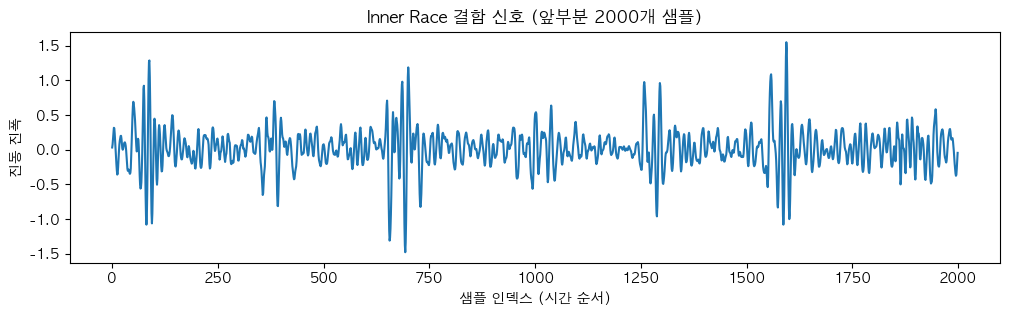

In [4]:
# 처음 2000개 샘플(약 0.04초 분량)만 그려본다
plt.figure(figsize=(12, 3))
plt.plot(signal[:2000])
plt.title('Inner Race 결함 신호 (앞부분 2000개 샘플)')
plt.xlabel('샘플 인덱스 (시간 순서)')
plt.ylabel('진동 진폭')
plt.show()

---
## STEP 2. 정상 신호 vs 손상 신호 비교

이론에서 배운 것처럼, **정상 베어링은 잔잔하고 규칙적인 파형**을,
**손상된 베어링은 특정 구간에서 충격(spike)이 반복되는 파형**을 보입니다.

4가지 클래스(Normal / Inner Race / Outer Race / Ball)의 신호를 같이 불러와서
실제로 파형이 어떻게 다른지 눈으로 확인해봅니다.

In [5]:
# 4가지 클래스를 대표하는 파일을 하나씩 로드
files = {
    'Normal':      'dataset/Time_Normal_1_098.mat',
    'Inner Race':  'dataset/IR007_1_110.mat',
    'Outer Race':  'dataset/OR007_6_1_136.mat',
    'Ball':        'dataset/B007_1_123.mat',
}

signals = {}
for label, path in files.items():
    m = loadmat(path)
    # 파일 안에서 '_DE_time'으로 끝나는 키를 자동으로 찾는다
    de_key = [k for k in m.keys() if k.endswith('_DE_time')][0]
    signals[label] = m[de_key].squeeze()
    print(f"{label:12s} | key={de_key:14s} | shape={signals[label].shape}")

Normal       | key=X098_DE_time   | shape=(483903,)
Inner Race   | key=X110_DE_time   | shape=(486224,)
Outer Race   | key=X136_DE_time   | shape=(486804,)
Ball         | key=X123_DE_time   | shape=(487384,)


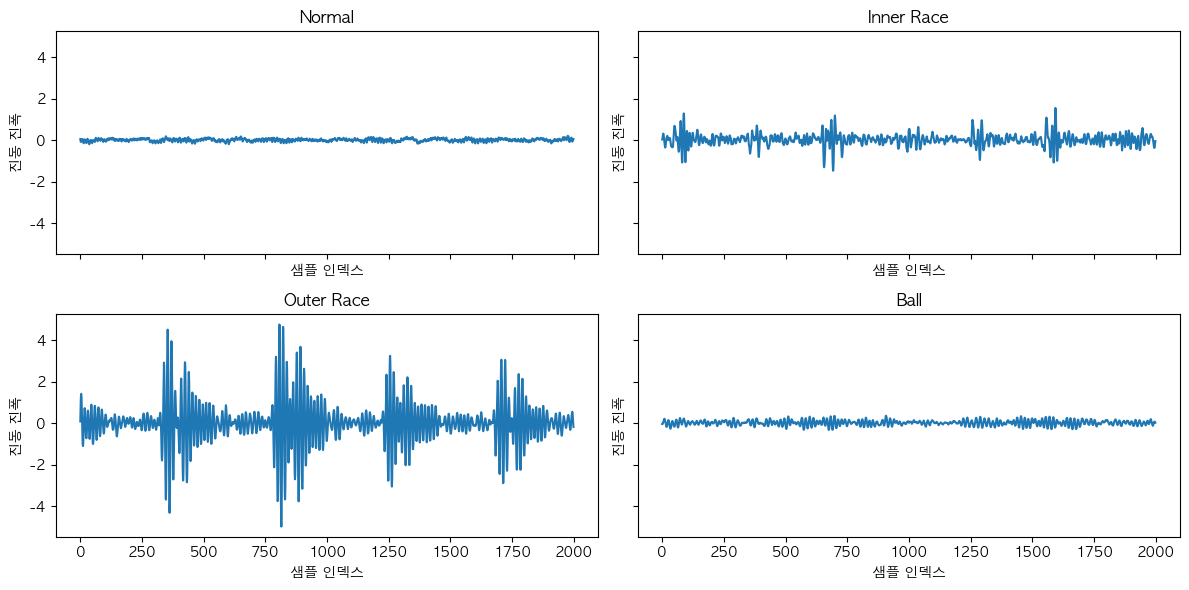

In [6]:
# 4개 신호를 같은 구간(앞 2000개 샘플)에서 비교
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=True)

for ax, (label, sig) in zip(axes.flatten(), signals.items()):
    ax.plot(sig[:2000])
    ax.set_title(label)
    ax.set_xlabel('샘플 인덱스')
    ax.set_ylabel('진동 진폭')

plt.tight_layout()
plt.show()

> 👉 Normal은 진폭이 작고 규칙적인 반면, Inner Race / Outer Race / Ball은
> 군데군데 진폭이 크게 튀는 **충격 파형(impulse)**이 반복되는 것을 확인할 수 있습니다.
> 이 차이를 딥러닝 모델이 데이터로부터 자동으로 학습하게 만드는 것이 오늘의 목표입니다.

---
## STEP 3. 윈도우 슬라이싱 (Sliding Window)

48만 개짜리 신호를 통째로 모델에 넣을 수는 없습니다.
딥러닝 모델은 **고정된 크기의 입력**만 받을 수 있기 때문입니다.

그래서 신호를 일정한 크기(`window_size`)로 잘라서 여러 개의 학습 샘플로 만듭니다.

```
[■■■■■□□□□□□□□□□]  ← 1번째 샘플 (0 ~ 2047)
[□■■■■■□□□□□□□□□]  ← 2번째 샘플 (1024 ~ 3071, stride만큼 이동)
[□□■■■■■□□□□□□□□]  ← 3번째 샘플 (2048 ~ 4095)
```

- `window_size` : 한 번에 잘라낼 길이 (여기서는 2048개)
- `step` (stride) : 다음 샘플을 만들 때 몇 개씩 이동할지 (여기서는 1024개, 즉 50% 겹침)

⚠️ **윈도우 크기 선택의 트레이드오프**
- 너무 짧으면 → 창문 안에 패턴이 다 안 들어와서 분류 성능 저하
- 너무 길면 → 모델 입력이 커져서 연산 부담 증가

💡 **`window_size`는 구체적으로 어떻게 정할까?**

- **결함의 반복 패턴이 윈도우 안에 최소 1번은 들어와야 한다**
   - 베어링이 손상되면, 축이 한 바퀴 돌 때마다 "딱" 하는 충격이 반복적으로 발생합니다.
   - 만약 `window_size`가 축이 한 바퀴 도는 데 걸리는 샘플 수보다 짧으면, 어떤 윈도우는 이 충격을
     하나도 포함하지 못해 정상/결함을 구분할 수 없습니다.
   - 예: 축이 1초에 30바퀴 돈다면 → 한 바퀴 = 1/30초 ≈ `fs`(48000Hz) 기준 1600개 샘플.
     `window_size=2048`이면 한 바퀴보다 길어서 충격 패턴이 최소 1번 들어옵니다.

→ 정리하면 "축 1바퀴 이상의 길이"를 고르고,
계산 효율을 위해 보통 2의 거듭제곱(512, 1024, 2048, 4096 ...)으로 맞춥니다.

💡 **그런데 왜 윈도우끼리 겹치게(overlap) 만들까?**

`step`을 `window_size`보다 작게 잡으면 이웃한 윈도우끼리 일부 구간이 겹칩니다.
이렇게 겹치게 만드는 이유는 크게 두 가지입니다.

1. **데이터 증강(augmentation)** : 겹치지 않게 자르면(`step=window_size`) 48만 개 신호에서
   약 234개의 윈도우만 나오지만, 50% 겹치게(`step=window_size/2`) 자르면 거의 2배인
   약 468개의 윈도우를 얻을 수 있어 학습 샘플 수가 늘어납니다.
2. **중요한 패턴이 잘리는 것을 방지** : 결함으로 인한 충격(impulse) 패턴이 신호 전체에
   고르게 퍼져 있지 않을 수 있는데, 한 윈도우의 경계에 패턴이 걸려 잘리더라도
   겹치는 다음 윈도우에는 그 패턴이 온전히 포함될 가능성이 높아집니다.

### 함수를 만들기 전에, 작은 예시로 손으로 먼저 잘라봅시다

바로 일반적인 함수(`sliding_window`) 코드를 보면 낯설 수 있으니,
48만 개짜리 실제 신호 대신 **0부터 19까지 숫자 20개로 된 작은 가짜 신호**로 먼저 연습해봅니다.

- `window_size = 5` (한 번에 5개씩 자른다)
- `step = 2` (다음 자를 때는 2칸씩 옆으로 이동한다)

파이썬의 슬라이싱 문법 `signal[시작:끝]`을 이용하면, 시작 위치(`start`)만 알면
`signal[start : start + window_size]`로 윈도우 하나를 잘라낼 수 있습니다.

In [7]:
# 0~19까지의 숫자로 이루어진 가짜 신호
toy_signal = np.arange(20)
print("가짜 신호:", toy_signal)

window_size = 5
step = 2

# 시작 위치(start)를 0, 2, 4로 바꿔가며 직접 잘라본다
window0 = toy_signal[0 : 0 + window_size]
window1 = toy_signal[2 : 2 + window_size]
window2 = toy_signal[4 : 4 + window_size]

print("1번째 윈도우 (start=0):", window0)
print("2번째 윈도우 (start=2):", window1)
print("3번째 윈도우 (start=4):", window2)

가짜 신호: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
1번째 윈도우 (start=0): [0 1 2 3 4]
2번째 윈도우 (start=2): [2 3 4 5 6]
3번째 윈도우 (start=4): [4 5 6 7 8]


### 이제 함수로 만들어 재사용하기

위 반복문 코드는 `toy_signal`, `window_size=5`, `step=2`에만 쓸 수 있게 고정되어 있습니다.
이 로직을 **함수**로 감싸두면, 신호와 `window_size`, `step`을 바꿔가며 어디서든 재사용할 수 있습니다.

아래 `sliding_window` 함수는 방금 작성한 반복문과 **완전히 같은 로직**입니다.
(`signal`, `window_size`, `step`이 함수의 입력으로 바뀌었을 뿐입니다.)

In [5]:
def sliding_window(signal, window_size=2048, step=1024):
    """
    긴 1차원 신호를 (window_size) 크기의 여러 조각(세그먼트)으로 잘라낸다.

    Parameters
    ----------
    signal : 1차원 numpy 배열, 원본 진동 신호
    window_size : 한 조각의 길이
    step : 조각을 잘라낼 때마다 이동할 거리 (step < window_size면 구간이 겹침)

    Returns
    -------
    segments : shape = (조각 개수, window_size) 인 2차원 배열
    """
    segments = []
    # 0부터 시작해서 step만큼씩 이동하며 window_size만큼 잘라낸다
    # len(signal) - window_size를 넘어서면 더 이상 자르지 않음 (마지막에 길이가 모자란 조각 방지)
    for start in range(0, len(signal) - window_size, step):
        segments.append(signal[start:start + window_size])
    return np.array(segments)

In [8]:
# Inner Race 신호(약 48만 개)에 윈도우 슬라이싱 적용
ir_signal = signals['Inner Race']
ir_segments = sliding_window(ir_signal, window_size=2048, step=1024)

print(f"원본 신호 길이: {len(ir_signal):,}")
print(f"슬라이싱 결과 shape: {ir_segments.shape}")
print(f"  → {ir_segments.shape[0]}개의 샘플, 각 샘플은 {ir_segments.shape[1]}개의 측정값")

원본 신호 길이: 486,224
슬라이싱 결과 shape: (473, 2048)
  → 473개의 샘플, 각 샘플은 2048개의 측정값


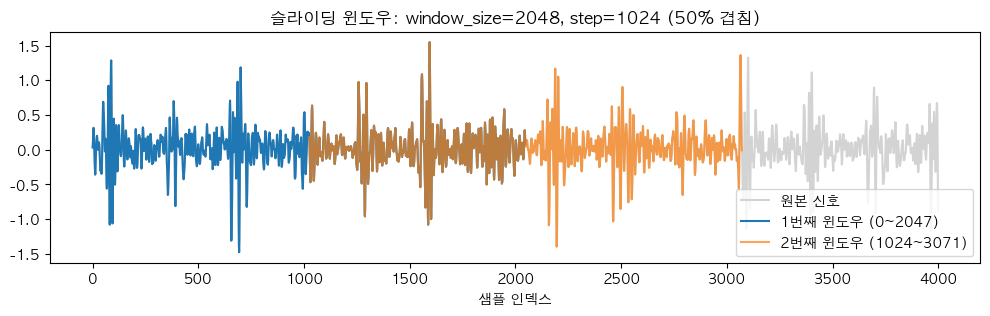

In [11]:
# 1번째, 2번째 윈도우가 원본 신호에서 어느 구간을 차지하는지 시각화
plt.figure(figsize=(12, 3))
plt.plot(ir_signal[:4000], color='lightgray', label='원본 신호')
plt.plot(range(0, 2048), ir_segments[0], label='1번째 윈도우 (0~2047)')
plt.plot(range(1024, 1024 + 2048), ir_segments[1], label='2번째 윈도우 (1024~3071)', alpha=0.7)
plt.title('슬라이딩 윈도우: window_size=2048, step=1024 (50% 겹침)')
plt.xlabel('샘플 인덱스')
plt.legend()
plt.show()

---
## STEP 4. FFT 변환 - 시간 정보를 주파수 정보로

**FFT (Fast Fourier Transform)** 는 복잡한 진동 신호를
"어떤 주기로 진동하는 성분이 얼마나 섞여 있는가"로 분해해주는 변환입니다.

- 피아노로 "도 + 미 + 솔" 화음을 동시에 쳤을 때, FFT는 "이 소리는 도, 미, 솔 세 음이 섞여있다"고 알려주는 것과 비슷합니다.
- 베어링이 손상되면 특정 주파수에서 진동이 유독 강하게 나타나는데,
  시간 영역(time domain)에서는 잘 안 보이던 패턴이 주파수 영역(frequency domain)에서는 뚜렷하게 보일 수 있습니다.

아래에서 **정상(Normal) 윈도우 1개**와 **내륜 손상(Inner Race) 윈도우 1개**를
시간 영역 / 주파수 영역으로 나란히 비교해봅니다.

파이썬에선 이 복잡한 FFT를 직접 구현할 필요 없이 구현되어 있는 함수를 사용하면 됩니다.

In [6]:
def compute_fft(segment, fs=48000):
    """
    하나의 시계열 윈도우(segment)를 주파수 영역으로 변환한다.

    Parameters
    ----------
    segment : 1차원 numpy 배열, 길이 = window_size
    fs : 샘플링 레이트 (Hz). 이 데이터는 48,000Hz로 수집됨

    Returns
    -------
    freqs    : 각 주파수 성분의 실제 주파수 값 (Hz) (시각화를 위해 출력)
    fft_vals : 각 주파수 성분의 세기(진폭)
    """
    n = len(segment)
    # np.fft.rfft : 실수 신호 전용 FFT → 대칭인 음수 주파수 부분을 자동으로 제거
    # np.abs    : 복소수 결과에서 "세기(magnitude)"만 추출
    # 학습에는 fft_vals만 필요!
    fft_vals = np.abs(np.fft.rfft(segment))[:n // 2]
    # rfftfreq : 각 성분이 실제로 몇 Hz에 해당하는지 계산
    freqs = np.fft.rfftfreq(n, d=1 / fs)[:n // 2]
    return freqs, fft_vals

In [14]:
# 정상 신호도 동일하게 윈도우 슬라이싱
normal_segments = sliding_window(signals['Normal'], window_size=2048, step=1024)

# 비교용으로 각각 1개 윈도우 선택 (같은 위치: 0번째 윈도우)
normal_seg = normal_segments[0]
ir_seg = ir_segments[0]

# FFT 적용
normal_freqs, normal_fft = compute_fft(normal_seg)
ir_freqs, ir_fft = compute_fft(ir_seg)

print(f"윈도우 1개 길이: {len(normal_seg)}")
print(f"FFT 결과 길이: {len(normal_fft)}  (= window_size // 2)")

윈도우 1개 길이: 2048
FFT 결과 길이: 1024  (= window_size // 2)


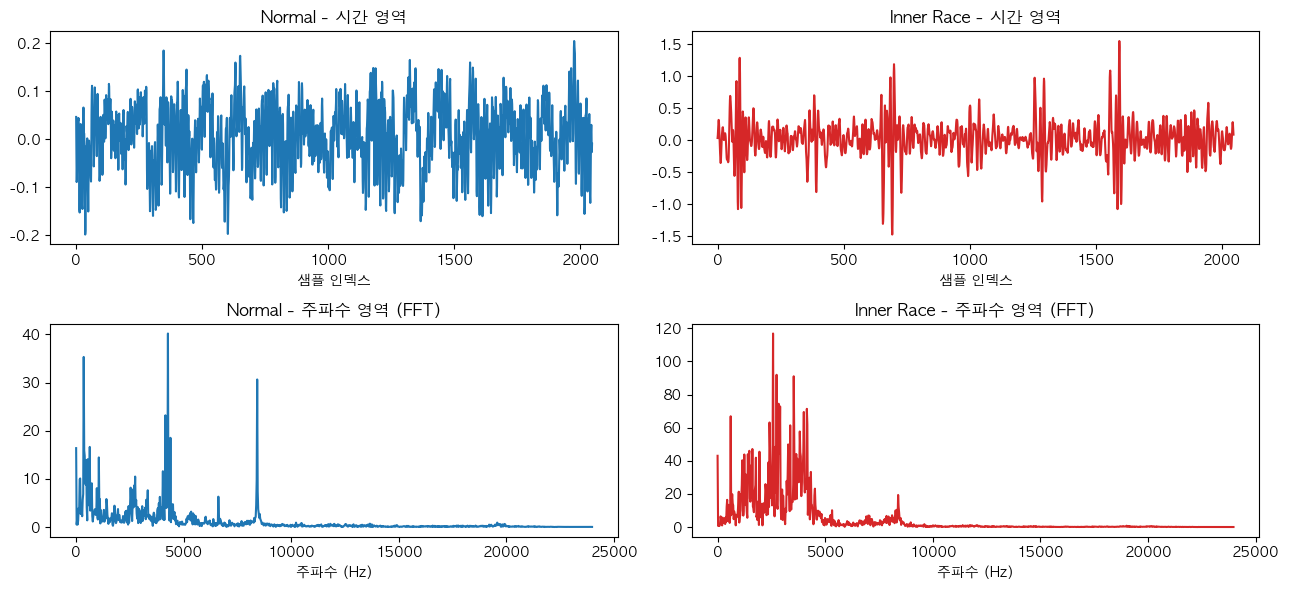

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6))

# 시간 영역 (위쪽)
axes[0, 0].plot(normal_seg)
axes[0, 0].set_title('Normal - 시간 영역')
axes[0, 0].set_xlabel('샘플 인덱스')

axes[0, 1].plot(ir_seg, color='tab:red')
axes[0, 1].set_title('Inner Race - 시간 영역')
axes[0, 1].set_xlabel('샘플 인덱스')

# 주파수 영역 (아래쪽)
axes[1, 0].plot(normal_freqs, normal_fft)
axes[1, 0].set_title('Normal - 주파수 영역 (FFT)')
axes[1, 0].set_xlabel('주파수 (Hz)')

axes[1, 1].plot(ir_freqs, ir_fft, color='tab:red')
axes[1, 1].set_title('Inner Race - 주파수 영역 (FFT)')
axes[1, 1].set_xlabel('주파수 (Hz)')

plt.tight_layout()
plt.show()

> 👉 시간 영역 그래프만 보면 두 신호의 차이가 잘 안 보일 수 있지만,
> 주파수 영역(FFT) 그래프에서는 Inner Race 신호에서 특정 주파수의 피크(peak)가
> Normal보다 뚜렷하게 솟아있는 것을 확인할 수 있습니다.
> → 이런 패턴 차이를 딥러닝 모델이 자동으로 학습하게 됩니다.

---
## STEP 5. 10개 파일 → 학습용 데이터셋 (X, y) 만들기

지금까지 파일 1개로 "윈도우 슬라이싱 → FFT" 과정을 확인했습니다.
이제 **10개 파일 전체**에 동일한 처리를 적용해서, 모델 학습에 사용할
입력(X)과 정답 레이블(y)을 만듭니다.

💡 **왜 train/test를 나눌까?**

딥러닝 모델을 학습시킬 때, 가진 데이터를 전부 학습에 써버리면
"이 모델이 새로운 데이터에도 잘 작동할까?"를 확인할 방법이 없습니다.

비유하자면, 학생에게 시험 문제와 정답을 미리 다 알려주고 공부시킨 뒤,
**똑같은 문제로 시험을 보는 것**과 같습니다. 학생은 100점을 받겠지만,
그게 "이 학생이 진짜로 개념을 이해했다"는 뜻은 아닙니다. 한 번도 본 적 없는
새로운 문제를 풀어봐야 진짜 실력을 알 수 있습니다.

그래서 데이터를 두 그룹으로 나눕니다.
- **Train(훈련) 데이터** : 모델이 "공부"하는 데 사용 — 정답(label)을 보여주고 패턴을 학습시킴
- **Test(평가) 데이터** : 모델이 한 번도 보지 못한 데이터로 "시험" — 학습이 끝난 후,
  새로운 데이터에서도 정상/결함을 잘 구분하는지 확인

이 노트북에서 만드는 모델의 최종 목표는 "처음 보는 진동 신호가 들어왔을 때
정상/내륜/외륜/볼 결함을 정확히 분류하는 것"이므로, **test 데이터는 train 데이터와
겹치지 않아야 이 목표를 제대로 평가**할 수 있습니다.

⚠️ **그런데 "겹치지 않게 나눈다"는 게 생각보다 까다롭습니다 (Data Leakage 방지)**

STEP 3에서 본 것처럼, 윈도우는 `step=1024`(window_size=2048의 절반)만큼씩 겹치며 만들어집니다.
만약 윈도우를 다 만든 **뒤에** 무작위로 train/test를 나누면, 바로 옆에 있는(절반이 겹치는)
윈도우가 한쪽은 train, 다른 쪽은 test로 들어갈 수 있습니다.
→ 이러면 "시험 문제와 거의 똑같은 연습문제를 미리 풀어본" 상황이 되어,
앞서 설명한 train/test 분리의 목적이 무색해지고 평가 정확도가 실제보다 높게 나옵니다.

그래서 각 파일의 **원본 신호를 시간 순서대로 앞부분(train) / 뒷부분(test)으로 먼저 나누고**,
그 다음에 각각 따로 윈도우 슬라이싱 + FFT를 적용합니다.

우선 앞에서 불러왔던 `signal` 변수에 담긴 신호의 크기를 살펴보겠습니다.

In [ ]:
print(signal.shape)

(486224,)

전체 signal의 크기가 486224이므로, 80% 비율을 적용하여 앞을 훈련 데이터로, 뒤를 테스트 데이터로 사용하겠습니다.

In [8]:
train_size = round(signal.shape[0] * 0.8)

train_signal = signal[:train_size]
test_signal = signal[train_size:]

print(train_signal.shape, test_signal.shape)

(388979,) (97245,)


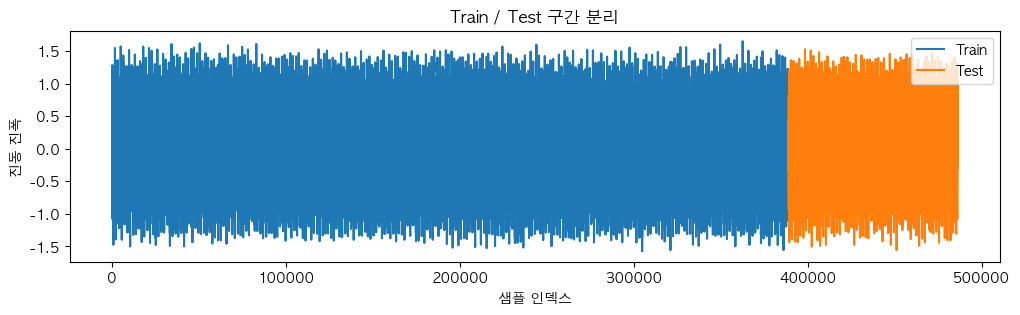

In [10]:
plt.figure(figsize=(12, 3))

# train_signal: x축 인덱스 0 ~ train_size-1, 파란색
plt.plot(np.arange(train_size), train_signal, color='tab:blue', label='Train')

# test_signal: x축 인덱스 train_size ~ 끝, 주황색 (이어서 그려지도록 시작 인덱스를 train_size로 맞춤)
plt.plot(np.arange(train_size, train_size + len(test_signal)), test_signal, color='tab:orange', label='Test')

plt.title('Train / Test 구간 분리')
plt.xlabel('샘플 인덱스')
plt.ylabel('진동 진폭')
plt.legend()
plt.show()

train/test split 기능을 언제든지 활용할 수 있도록 함수 형태로 저장하겠습니다.

In [11]:
def train_test_split(signal, train_size=0.8):
    size = round(signal.shape[0] * train_size)

    train_signal = signal[:size]
    test_signal = signal[size:]
    return train_signal, test_signal

이렇게 분리된 데이터에 윈도우 슬라이싱과 FFT 변환을 적용합니다.

In [16]:
train_segments = sliding_window(train_signal)
test_segments = sliding_window(test_signal)

train_data = []
test_data = []

for segment in train_segments:
    _, data = compute_fft(segment)
    train_data.append(data)

for segment in test_segments:
    _, data = compute_fft(segment)
    test_data.append(data)

train_data = np.array(train_data)
test_data = np.array(test_data)

print(train_data.shape, test_data.shape)

(378, 1024) (93, 1024)


---
## STEP 6. 정규화 (Normalization)

딥러닝 모델은 입력값의 **크기(스케일)** 차이에 민감합니다.

딥러닝 모델은 기본적으로 수치가 큰 데이터에 크게 반응을 하는데 수치의 편차가 클 경우 수치가 작은 데이터들을 무시하게 될 우려가 있습니다.

FFT 결과값은 주파수마다 크기가 크게 차이날 수 있으므로, **평균 0, 표준편차 1**로 맞춰줍니다 (`StandardScaler`).

⚠️ **Data Leakage 방지**

`StandardScaler`는 **train 데이터에서만** 평균/표준편차를 계산합니다 (`fit`).
test 데이터는 그 통계값으로 **변환만** 합니다 (`transform`).

→ 만약 전체 데이터(train+test)로 먼저 정규화 통계를 계산하면, test 데이터의 정보가
학습 과정에 "새어 들어가는"(Data Leakage) 문제가 생깁니다. STEP 5에서 윈도잉 전에
train/test 구간을 먼저 나눠둔 것도 같은 이유입니다.

In [17]:
print(f"X_train: {train_data.shape}, X_test: {test_data.shape}")

# 정규화 전 train 데이터의 평균/표준편차 (참고용, 0번째 주파수 성분 기준)
print(f"\n정규화 전 - X_train[:, 0] 평균: {train_data[:, 0].mean():.2f}, 표준편차: {train_data[:, 0].std():.2f}")

# train 데이터로 scaler를 학습(fit)하고, train/test 모두 변환(transform)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)   # train: fit + transform
test_scaled = scaler.transform(test_data)         # test : transform만 (fit 하지 않음!)

print(f"정규화 후 - X_train[:, 0] 평균: {train_scaled[:, 0].mean():.2f}, 표준편차: {train_scaled[:, 0].std():.2f}")

X_train: (378, 1024), X_test: (93, 1024)

정규화 전 - X_train[:, 0] 평균: 42.53, 표준편차: 3.80
정규화 후 - X_train[:, 0] 평균: -0.00, 표준편차: 1.00


#### 🏭 실무에 적용한다면?

오늘은 "같은 설비, 같은 측정 회차"의 신호를 앞/뒤로 나눠 train/test로 사용했습니다.
실제 현장 데이터로 모델을 만들 때는, 아래 질문을 한 단계 더 점검해보세요.

#### 📋 전체 흐름 정리

| 단계 | 내용 | 핵심 포인트 |
|---|---|---|
| **1. 데이터 불러오기** | `.mat` 파일에서 진동 신호(시계열 데이터) 읽기 | - |
| **2. Train / Test 분리** | 신호를 앞부분(train)·뒷부분(test)으로 분리 | - **훈련 데이터**: 모델이 학습에 사용<br>- **테스트 데이터**: 모델 성능을 확인할 실제 데이터 |
| **3. 윈도우 슬라이딩** | 긴 신호를 일정한 크기로 잘라서 여러 개의 샘플로 변환 | - 전체 패턴을 한 번에 입력하는 것은 불가능<br>- 이상 패턴을 충분히 담을 수 있는 크기로 분리<br>- 구간끼리 겹치도록(overlap) 지정 |
| **4. FFT 적용** | 시간 영역 신호 → 주파수 영역 신호로 변환 | 패턴을 더 쉽게 구분할 수 있게 됨 |
| **5. 정규화** | 평균 0, 표준편차 1로 스케일 통일 (`StandardScaler`) | 모델은 값의 크기 차이에 민감하므로 비슷한 크기로 맞춰줌 |

```
.mat 파일
   ↓ ① 불러오기
원본 신호
   ↓ ② train / test 분리
   ↓ ③ 윈도우 슬라이싱 (겹치게 자르기)
   ↓ ④ FFT 변환
   ↓ ⑤ 정규화 (StandardScaler)
딥러닝 모델 입력 데이터 완성!
```